# Field Mapping 04 - Spatial Correlation Analysis

**Report Date:** March 2025  
**Dataset:** Oregon Willamette Valley Agricultural Fields (50 fields)

## Executive Summary

This notebook analyzes spatial correlations between satellite metrics, soil properties, and terrain data for 4 randomly selected fields from the 50-field dataset.

### Key Findings Summary Table

| Section | Finding | Metric |
|---------|---------|--------|
| **7.2 Satellite-Terrain** | Correlation between satellite indices and terrain properties | r values |
| **7.3 Key Findings** | Summary of significant correlations | p < 0.05 |

## Section 1: Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import rasterio
from pyproj import Transformer
from rasterio.warp import calculate_default_transform, reproject, Resampling
from scipy import stats
import json
import os
import random

# Set random seed for reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Configuration Parameters
MIN_PIXEL_COUNT = 30  # Minimum pixels required for valid correlation
SATELLITE_METRICS = ['ndvi', 'msavi', 'evi', 'ndmi']
SOIL_PROPERTIES = ['ph', 'om_pct', 'clay_pct', 'sand_pct', 'cec', 'awc', 'silt_pct']
TERRAIN_PROPERTIES = ['elevation', 'slope', 'aspect']

# Define absolute paths - notebook runs from /notebooks/ so go up one level
PROJECT_ROOT = '/workspaces/ag-skills-demo'
DATA_DIR = os.path.join(PROJECT_ROOT, 'docs/assignment-03')
TERRAIN_DIR = os.path.join(PROJECT_ROOT, 'data/terrain')
SOIL_DIR = os.path.join(PROJECT_ROOT, 'data/soil')
SOIL_PROPS_DIR = os.path.join(PROJECT_ROOT, 'data/soil_properties')
SATELLITE_DIR = os.path.join(PROJECT_ROOT, 'data/satellite')
TERRAIN_RESAMPLED_DIR = os.path.join(PROJECT_ROOT, 'data/terrain_resampled')
SOIL_PROPS_RESAMPLED_DIR = os.path.join(PROJECT_ROOT, 'data/soil_properties_resampled')
DOCS_DIR = os.path.join(PROJECT_ROOT, 'docs/assignment-03')

os.makedirs(TERRAIN_RESAMPLED_DIR, exist_ok=True)
os.makedirs(SOIL_PROPS_RESAMPLED_DIR, exist_ok=True)
print('Configuration loaded:')
print(f'  MIN_PIXEL_COUNT: {MIN_PIXEL_COUNT}')
print(f'  SATELLITE_METRICS: {SATELLITE_METRICS}')
print(f'  SOIL_PROPERTIES: {SOIL_PROPERTIES}')
print(f'  TERRAIN_PROPERTIES: {TERRAIN_PROPERTIES}')



Configuration loaded:
  MIN_PIXEL_COUNT: 30
  SATELLITE_METRICS: ['ndvi', 'msavi', 'evi', 'ndmi']
  SOIL_PROPERTIES: ['ph', 'om_pct', 'clay_pct', 'sand_pct', 'cec']
  TERRAIN_PROPERTIES: ['elevation', 'slope', 'aspect']


## Section 2: Helper Functions

In [2]:
def calculate_pixel_correlation(array1, array2, min_pixels=MIN_PIXEL_COUNT, nodata_value=-9999):
    """Calculate Pearson correlation between two arrays, handling NoData."""
    valid_mask = ~np.isnan(array1) & ~np.isnan(array2)
    if nodata_value is not None:
        valid_mask = valid_mask & (array1 != nodata_value) & (array2 != nodata_value)
    valid_count = np.sum(valid_mask)
    if valid_count < min_pixels:
        return np.nan, np.nan, valid_count
    x = array1[valid_mask]
    y = array2[valid_mask]
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan, valid_count
    r, p = stats.pearsonr(x, y)
    return r, p, valid_count


def calculate_polygon_correlation(soil_tiff_path, sat_tiff_path, labels_json_path, property_column):
    """Calculate correlation between satellite and soil at polygon level."""
    with open(labels_json_path) as f:
        labels = json.load(f)
    with rasterio.open(soil_tiff_path) as src:
        soil_data = src.read(1)
    with rasterio.open(sat_tiff_path) as src:
        sat_data = src.read(1)
    min_h = min(sat_data.shape[0], soil_data.shape[0])
    min_w = min(sat_data.shape[1], soil_data.shape[1])
    sat_crop = sat_data[:min_h, :min_w]
    soil_crop = soil_data[:min_h, :min_w]
    polygon_means = []
    polygon_values = []
    label_to_mukey = labels.get('label_to_mukey', {})
    soil_defs = labels.get('soil_definitions', {})
    for label_id in label_to_mukey.keys():
        label_int = int(label_id)
        soil_def = soil_defs.get(label_id, {})
        property_value = soil_def.get(property_column)
        if property_value is None:
            continue
        polygon_mask = (soil_crop == label_int)
        if np.sum(polygon_mask) == 0:
            continue
        sat_mean = np.nanmean(sat_crop[polygon_mask])
        polygon_means.append(sat_mean)
        polygon_values.append(float(property_value))
    if len(polygon_means) < 3:
        return np.nan, np.nan, len(polygon_means)
    r, p = stats.pearsonr(polygon_means, polygon_values)
    return r, p, len(polygon_means)


def get_polygon_stats(soil_tiff_path, sat_tiff_path, labels_json_path, property_column):
    """Get per-polygon statistics for display."""
    with open(labels_json_path) as f:
        labels = json.load(f)
    with rasterio.open(soil_tiff_path) as src:
        soil_data = src.read(1)
    with rasterio.open(sat_tiff_path) as src:
        sat_data = src.read(1)
    min_h = min(sat_data.shape[0], soil_data.shape[0])
    min_w = min(sat_data.shape[1], soil_data.shape[1])
    sat_crop = sat_data[:min_h, :min_w]
    soil_crop = soil_data[:min_h, :min_w]
    results = []
    label_to_mukey = labels.get('label_to_mukey', {})
    soil_defs = labels.get('soil_definitions', {})
    for label_id in label_to_mukey.keys():
        label_int = int(label_id)
        soil_def = soil_defs.get(label_id, {})
        property_value = soil_def.get(property_column)
        if property_value is None:
            continue
        polygon_mask = (soil_crop == label_int)
        if np.sum(polygon_mask) == 0:
            continue
        sat_mean = np.nanmean(sat_crop[polygon_mask])
        sat_std = np.nanstd(sat_crop[polygon_mask])
        results.append({
            'polygon': label_id,
            'soil_type': soil_def.get('muname', 'Unknown'),
            'property_value': float(property_value),
            'sat_mean': sat_mean,
            'sat_std': sat_std,
            'n_pixels': np.sum(polygon_mask)
        })
    return results


def load_tiff(tiff_path):
    """Load TIFF file and return data array and valid pixel mask."""
    with rasterio.open(tiff_path) as src:
        data = src.read(1)
        nodata = src.nodata if src.nodata is not None else -9999
        valid_mask = ~np.isnan(data)
        if nodata is not None and not np.isnan(nodata):
            valid_mask = valid_mask & (data != nodata)
    return data, valid_mask, nodata


def load_tiff_with_nodata(tiff_path):
    """Load TIFF file and return data with nan substituted for nodata."""
    with rasterio.open(tiff_path) as src:
        data = src.read(1)
        nodata = src.nodata if src.nodata is not None else -9999
        plot_data = np.where(data == nodata, np.nan, data)
    return plot_data, None, nodata


def resample_to_match(source_path, reference_path, output_path=None):
    """Resample source raster to exactly match reference raster's extent and dimensions."""
    import rasterio
    from rasterio.warp import reproject, Resampling
    
    with rasterio.open(reference_path) as ref:
        ref_crs = ref.crs
        ref_width = ref.width
        ref_height = ref.height
        ref_bounds = ref.bounds
        
    with rasterio.open(source_path) as src:
        # Create transform that maps to reference's pixel grid
        transform = rasterio.transform.from_bounds(
            ref_bounds.left, ref_bounds.bottom, 
            ref_bounds.right, ref_bounds.top,
            ref_width, ref_height
        )
        
        # Create output array
        result = np.zeros((ref_height, ref_width), dtype=np.float32)
        
        # Reproject
        reproject(source=src.read(1), destination=result,
                  src_transform=src.transform, src_crs=src.crs,
                  dst_transform=transform, dst_crs=ref_crs,
                  resampling=Resampling.bilinear)
        
        if output_path:
            kwargs = src.meta.copy()
            kwargs.update({
                'crs': ref_crs, 
                'transform': transform, 
                'width': ref_width, 
                'height': ref_height,
                'dtype': 'float32'
            })
            with rasterio.open(output_path, 'w', **kwargs) as dst:
                dst.write(result, 1)
            return output_path
        else:
            return result

def load_soil_with_properties(soil_tiff_path, labels_json_path, property_column):
    """Convert soil mukey integers to property values using labels JSON."""
    with open(labels_json_path) as f:
        labels = json.load(f)
    label_to_mukey = labels.get('label_to_mukey', {})
    soil_defs = labels.get('soil_definitions', {})
    label_to_value = {}
    for label_id, mukey_str in label_to_mukey.items():
        soil_def = soil_defs.get(label_id, {})
        value = soil_def.get(property_column)
        if value:
            label_to_value[int(label_id)] = float(value)
    with rasterio.open(soil_tiff_path) as src:
        data = src.read(1)
    output = np.full_like(data, np.nan, dtype=np.float64)
    for label_id, value in label_to_value.items():
        output[data == label_id] = value
    return output


def get_or_resample_terrain(field_id, terrain_prop, satellite_metric='ndvi'):
    """Get terrain data from pre-resampled 10m terrain files."""
    # Use pre-resampled terrain (already at 10m to match satellite)
    resampled_path = f'{TERRAIN_RESAMPLED_DIR}/{field_id}_{terrain_prop}.tif'
    if os.path.exists(resampled_path):
        return load_tiff_with_nodata(resampled_path)
    # Fallback to original terrain if resampled not available
    terr_path = f'{TERRAIN_DIR}/{field_id}_{terrain_prop}.tif'
    if os.path.exists(terr_path):
        return load_tiff_with_nodata(terr_path)
    return None, None, None


SOIL_PROPERTY_DISPLAY = {'ph': 'pH', 'om_pct': 'Organic Matter (%)', 'clay_pct': 'Clay (%)', 
                         'sand_pct': 'Sand (%)', 'cec': 'CEC (meq/100g)'}
SATELLITE_DISPLAY = {'ndvi': 'NDVI', 'msavi': 'MSAVI', 'evi': 'EVI', 'ndmi': 'NDMI'}
TERRAIN_DISPLAY = {'elevation': 'Elevation (m)', 'slope': 'Slope (deg)', 'aspect': 'Aspect (deg)'}

print('Helper functions loaded.')

def plot_correlation_scatter(x_data, y_data, x_label, y_label, field_id, correlation_r, correlation_p, figsize=(6, 5)):
    """Create scatter plot with regression line and correlation stats."""
    fig, ax = plt.subplots(figsize=figsize)
    valid_mask = ~np.isnan(x_data) & ~np.isnan(y_data)
    x_valid = x_data[valid_mask]
    y_valid = y_data[valid_mask]
    if len(x_valid) == 0:
        ax.text(0.5, 0.5, 'No valid data for correlation', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{field_id}: {x_label} vs {y_label}')
        plt.tight_layout()
        return fig
    ax.scatter(x_valid, y_valid, alpha=0.4, s=15, c='steelblue', edgecolors='none')
    if not np.isnan(correlation_r) and np.std(x_valid) > 0 and np.std(y_valid) > 0:
        z = np.polyfit(x_valid, y_valid, 1)
        p = np.poly1d(z)
        x_line = np.linspace(x_valid.min(), x_valid.max(), 100)
        ax.plot(x_line, p(x_line), 'r-', lw=2, label=f'r = {correlation_r:.3f}')
        sig_star = '***' if correlation_p < 0.001 else ('**' if correlation_p < 0.01 else ('*' if correlation_p < 0.05 else ''))
        ax.text(0.05, 0.95, f'p = {correlation_p:.2e} {sig_star}', transform=ax.transAxes, fontsize=10, va='top')
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel(y_label, fontsize=11)
    ax.set_title(f'{field_id}: {x_label} vs {y_label}', fontsize=11, fontweight='bold')
    if not np.isnan(correlation_r):
        ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


def get_or_resample_soil(field_id, soil_prop, satellite_metric='ndvi'):
    """Get soil property data from pre-resampled 10m soil property files."""
    # Use pre-resampled soil properties (already at 10m to match satellite)
    resampled_path = f'{SOIL_PROPS_RESAMPLED_DIR}/{field_id}_soil_{soil_prop}.tif'
    if os.path.exists(resampled_path):
        return load_tiff_with_nodata(resampled_path)
    # Fallback to original soil properties if resampled not available
    soil_path = f'{SOIL_PROPS_DIR}/{field_id}_soil_{soil_prop}.tif'
    if os.path.exists(soil_path):
        return load_tiff_with_nodata(soil_path)
    return None, None, None



Helper functions loaded.


## Section 3: Data Loading

In [3]:
# Load field boundaries
gdf = gpd.read_file(f'{DATA_DIR}/fields_complete.geojson')
print(f'Loaded {len(gdf)} fields')

# Load slope/aspect statistics
slope_df = pd.read_csv(f'{PROJECT_ROOT}/data/field_slope_aspect.csv')
print(f'Loaded slope/aspect data for {len(slope_df)} fields')

Loaded 50 fields
Loaded slope/aspect data for 50 fields


## Section 4: Field Selection

In [4]:
# Select 4 random fields
selected_fields = random.sample(list(gdf['field_id']), 4)
print(f'Selected fields (seed={RANDOM_SEED}): {selected_fields}')

# Display field info
field_info = gdf[gdf['field_id'].isin(selected_fields)][['field_id', 'area_acres', 'cdl_crop', 'lat', 'lon']]
print('\nField Information:')
print(field_info.to_string(index=False))

Selected fields (seed=42): ['WV_AG_041', 'WV_AG_008', 'WV_AG_002', 'WV_AG_048']

Field Information:
 field_id  area_acres     cdl_crop       lat         lon
WV_AG_002   66.794644 Winter Wheat 44.188688 -123.183989
WV_AG_008   13.584710 Winter Wheat 44.592012 -122.698694
WV_AG_041   10.785175 Winter Wheat 44.450616 -123.102804
WV_AG_048   15.112003 Winter Wheat 44.184532 -123.171003


## Section 5: Per-Field Data Showcase

For each selected field, we display CDL crop type, soil maps, terrain maps, and satellite maps.

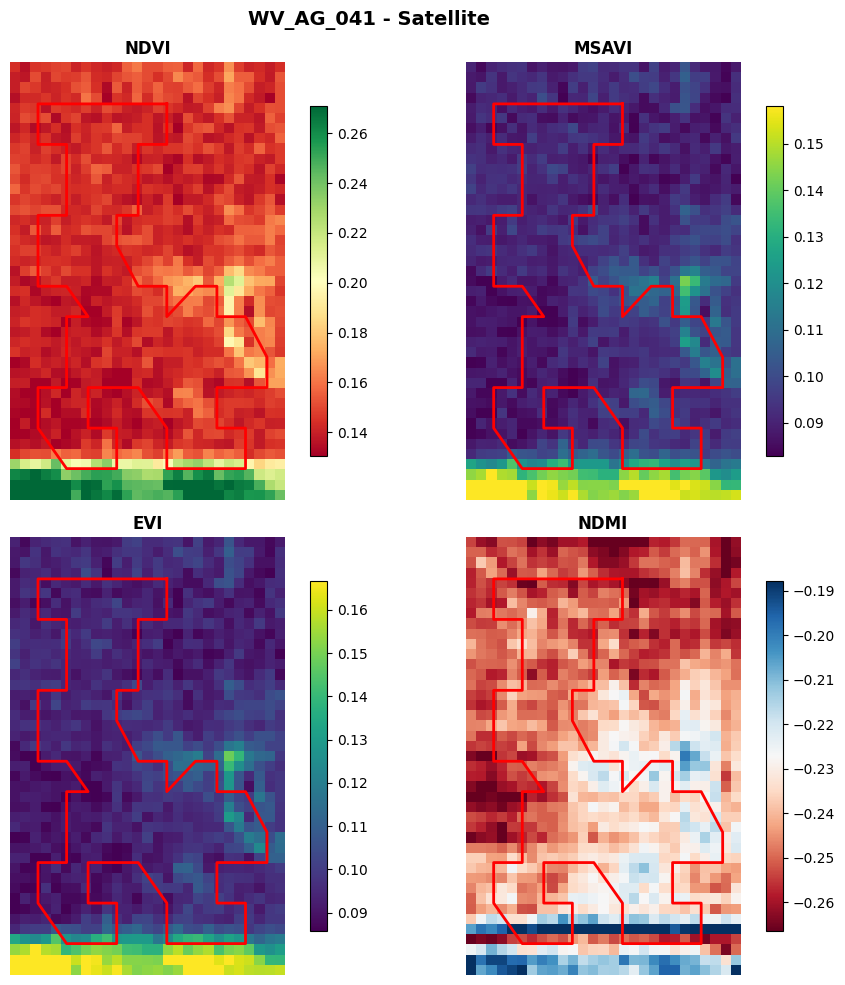

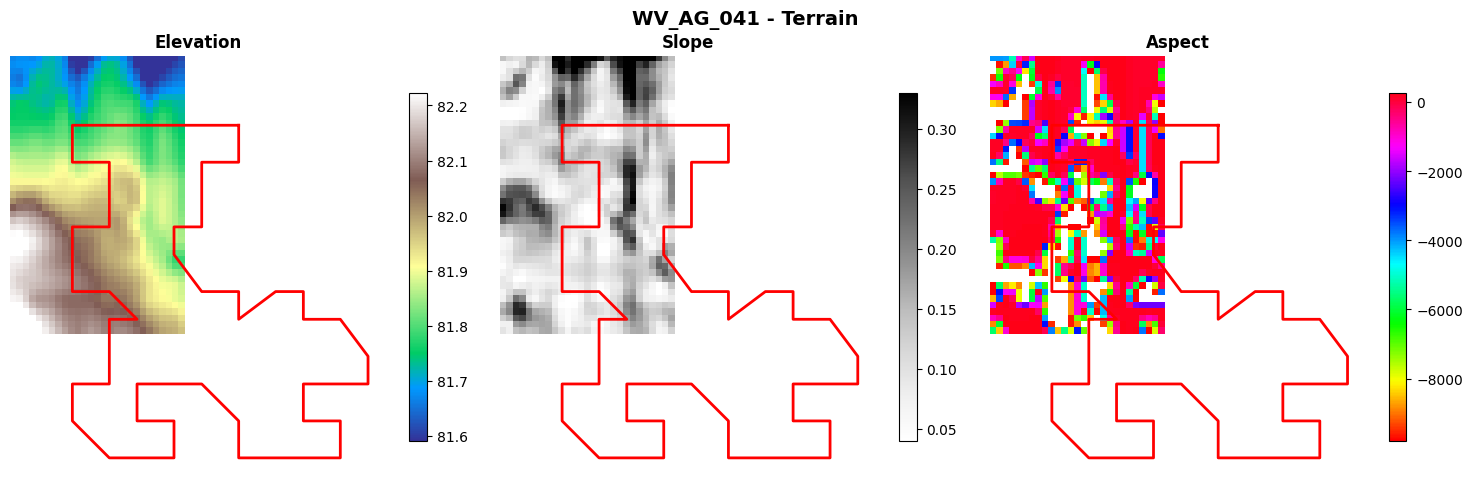

Soil data not available for WV_AG_041


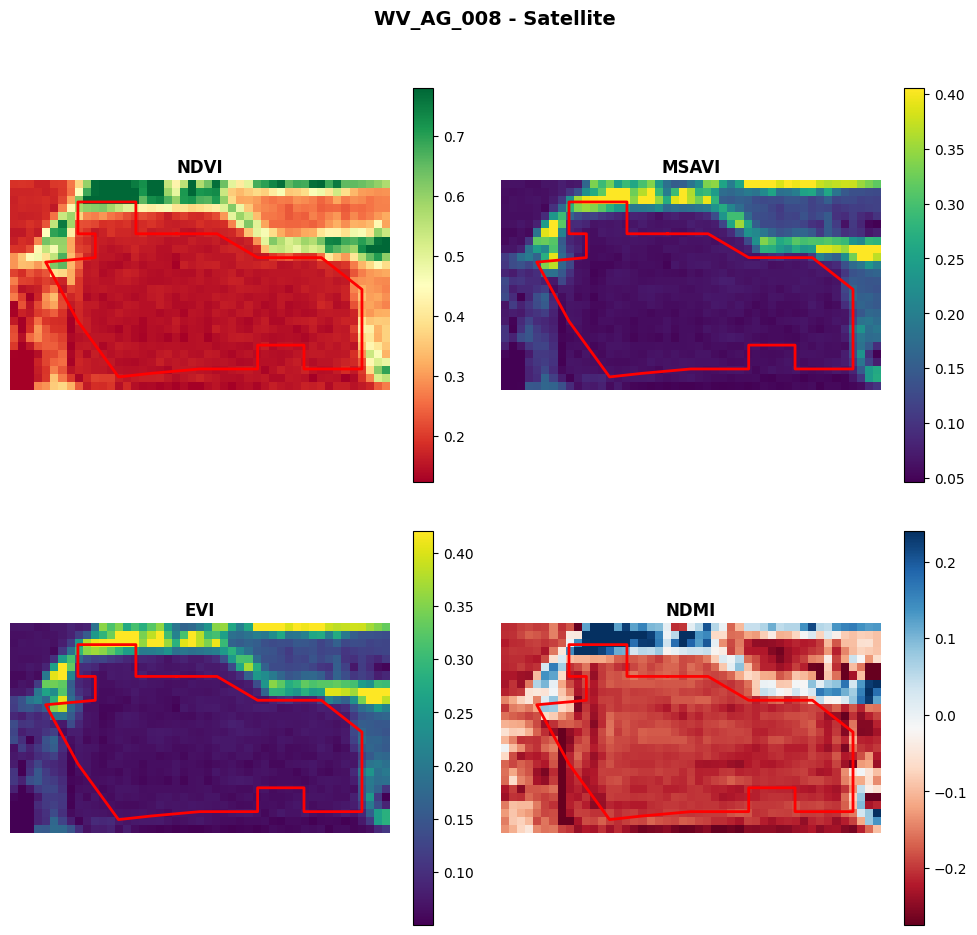

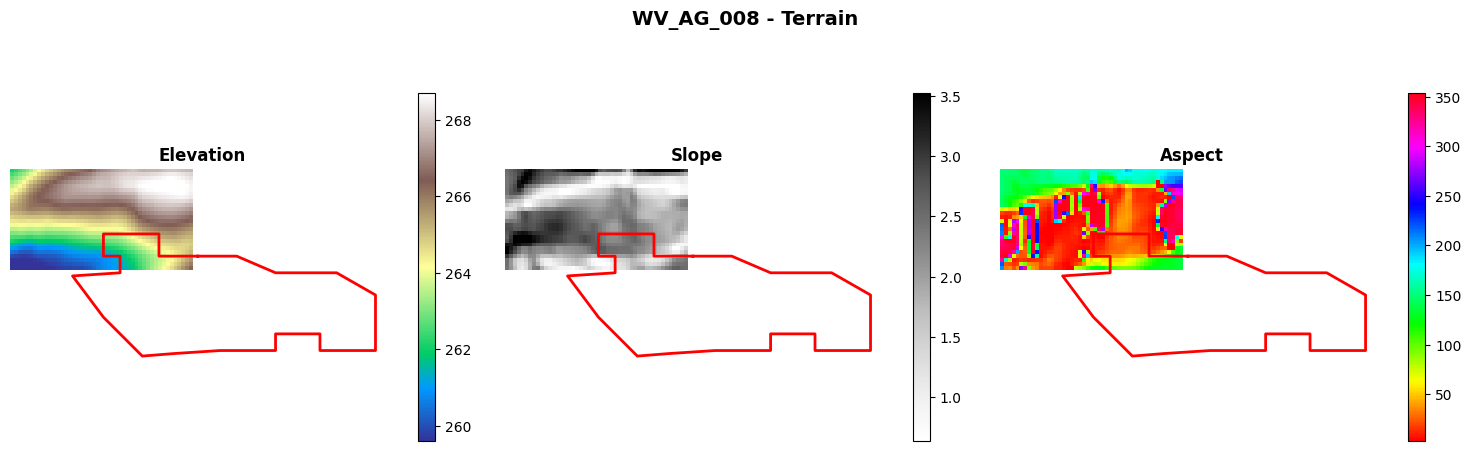

Soil data not available for WV_AG_008


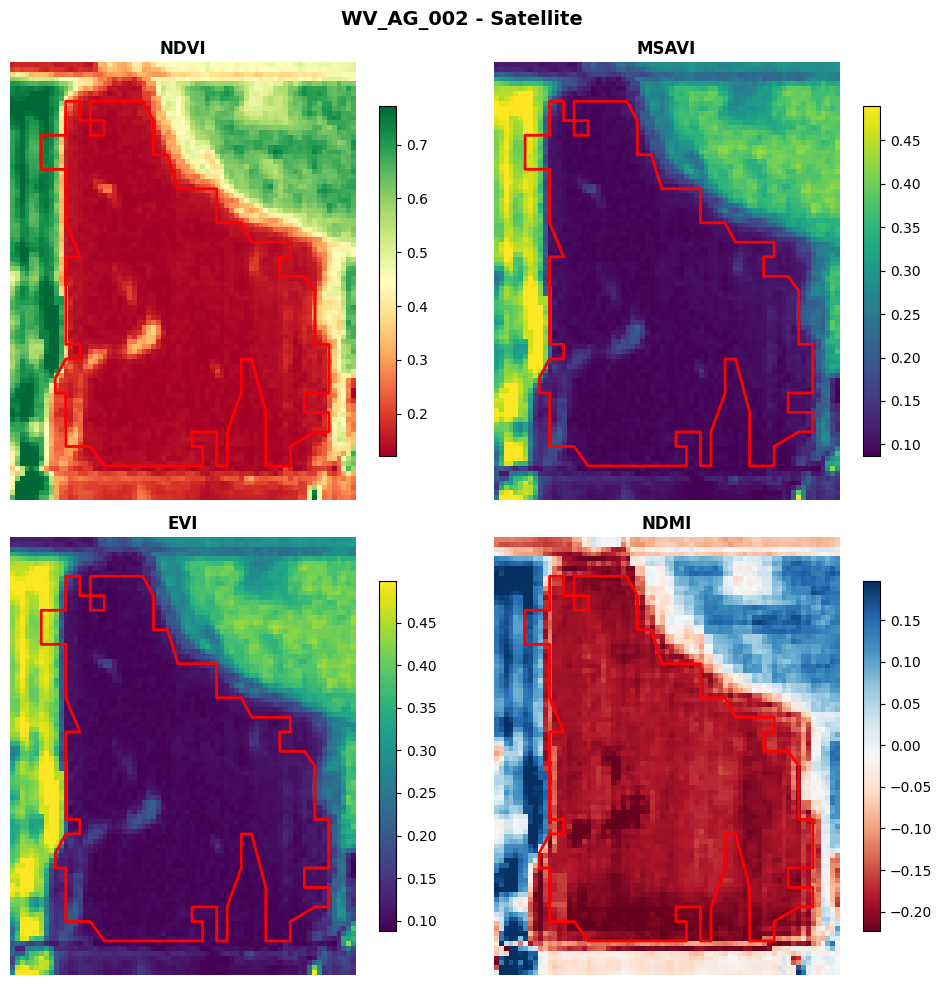

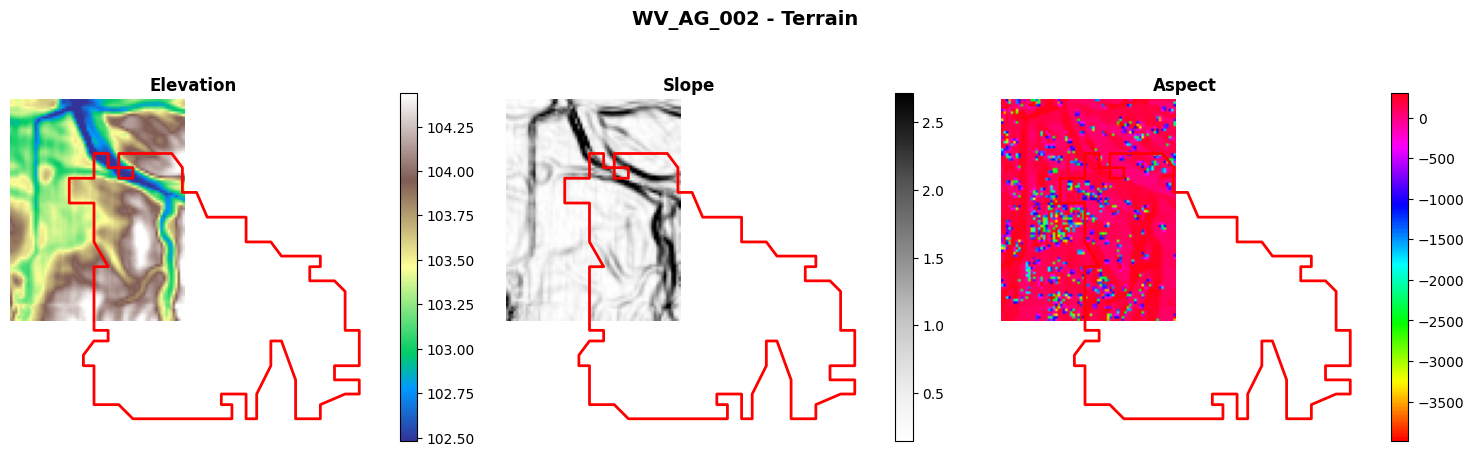

Soil data not available for WV_AG_002


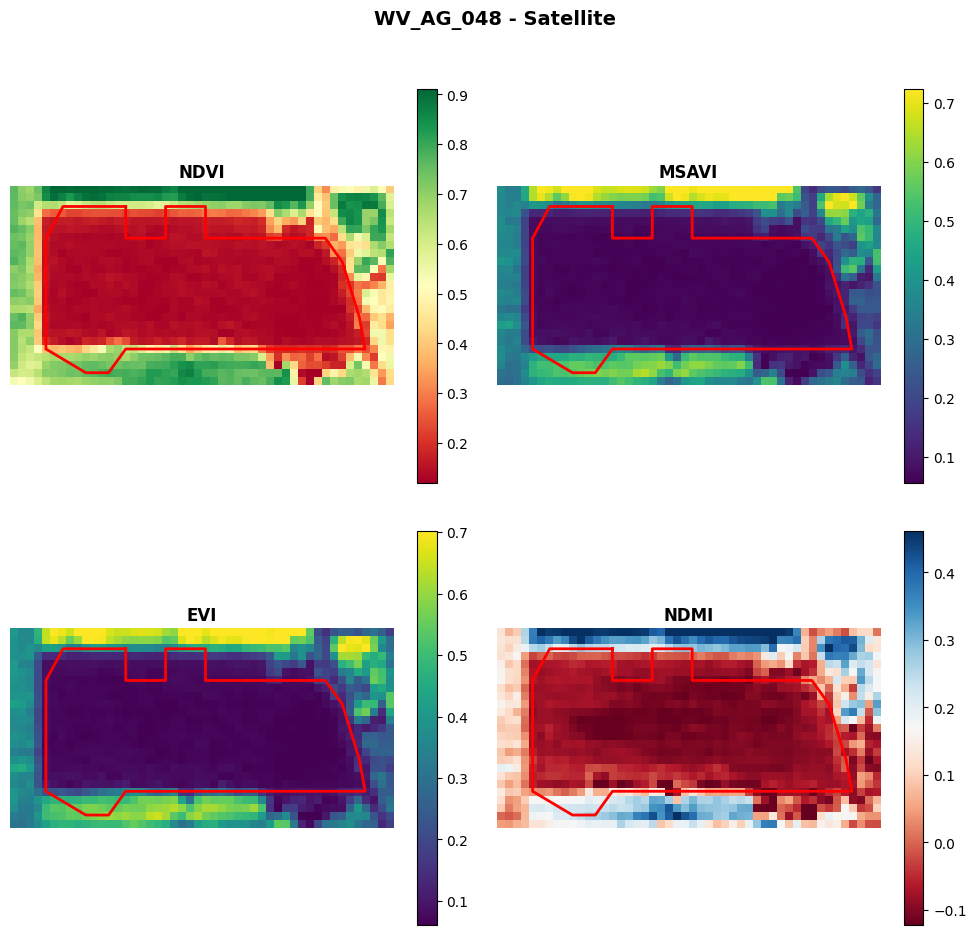

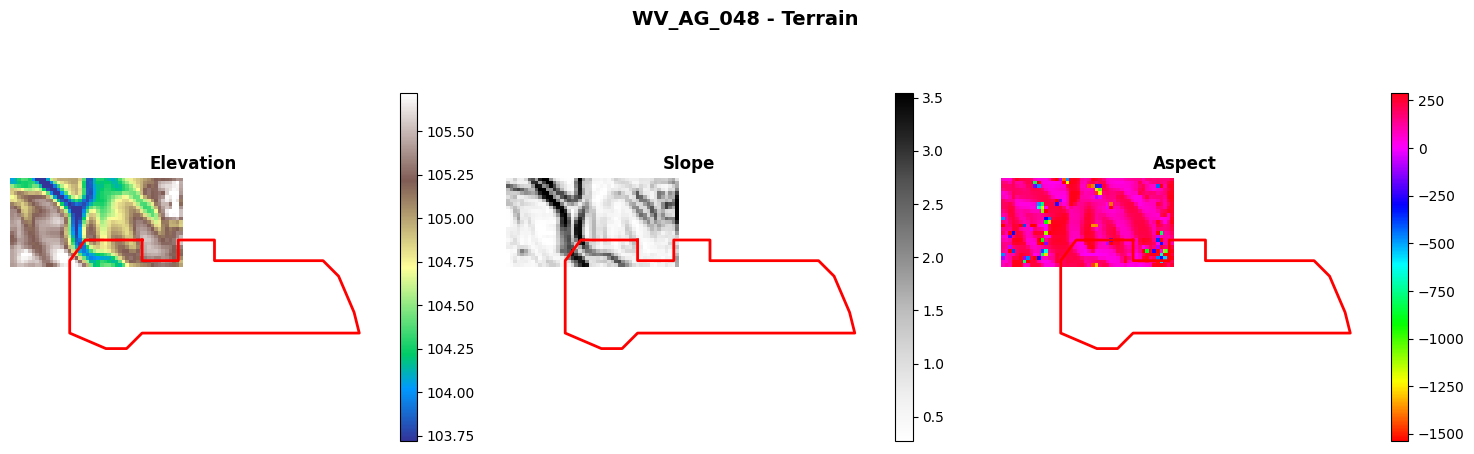

Soil data not available for WV_AG_048
Image maps complete.


In [5]:
# Section 5: Per-Field Image Maps
# Display satellite, terrain, and soil property maps with colorbars and field boundaries

from pyproj import Transformer

SAT_CMAPS = {'ndvi': 'RdYlGn', 'msavi': 'viridis', 'evi': 'viridis', 'ndmi': 'RdBu'}
TERRAIN_CMAPS = {'elevation': 'terrain', 'slope': 'Greys', 'aspect': 'hsv'}
SOIL_CMAPS = {'ph': 'coolwarm', 'om_pct': 'YlGn', 'clay_pct': 'YlOrBr', 'sand_pct': 'YlGnBu', 'cec': 'Purples'}

def get_field_boundary_pixels(field_id, raster_path):
    """Get field boundary in pixel coordinates for a given raster."""
    global gdf
    
    # Get field geometry
    field_geom = gdf[gdf['field_id'] == field_id].geometry.iloc[0]
    
    # Get raster info
    with rasterio.open(raster_path) as src:
        transform = src.transform
        raster_crs = src.crs
    
    # Get field CRS
    field_crs = gdf.crs
    
    # Create transformer from field CRS to raster CRS
    transformer = Transformer.from_crs(field_crs, raster_crs, always_xy=True)
    
    # Convert polygon to pixel coordinates
    if field_geom.geom_type == 'Polygon':
        coords = [list(field_geom.exterior.coords)]
    elif field_geom.geom_type == 'MultiPolygon':
        coords = [list(p.exterior.coords) for p in field_geom.geoms]
    else:
        return None
    
    # Transform each point and convert to pixel coords
    pixel_coords = []
    for poly in coords:
        poly_pixels = []
        for lon, lat in poly:
            # Transform from field CRS to raster CRS
            x, y = transformer.transform(lon, lat)
            # Convert to pixel coordinates
            col, row = ~transform * (x, y)
            poly_pixels.append((col, row))
        pixel_coords.append(poly_pixels)
    
    return pixel_coords


for field_id in selected_fields:
    # Get reference raster paths for each data type
    sat_ref = f'{SATELLITE_DIR}/{field_id}_ndvi.tif'
    terr_ref = f'{TERRAIN_RESAMPLED_DIR}/{field_id}_elevation.tif'
    soil_ref = f'{SOIL_PROPS_RESAMPLED_DIR}/{field_id}_soil_ph.tif'
    
    # Get boundaries in pixel coordinates for each raster
    bounds_sat = get_field_boundary_pixels(field_id, sat_ref)
    bounds_terr = get_field_boundary_pixels(field_id, terr_ref)
    bounds_soil = get_field_boundary_pixels(field_id, soil_ref)
    
    # --- Satellite 2x2 ---
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    fig.suptitle(f'{field_id} - Satellite', fontsize=14, fontweight='bold')
    
    for idx, m in enumerate(SATELLITE_METRICS):
        ax = axes[idx//2, idx%2]
        data, _, _ = load_tiff_with_nodata(f'{SATELLITE_DIR}/{field_id}_{m}.tif')
        
        vmin = np.nanpercentile(data, 2)
        vmax = np.nanpercentile(data, 98)
        im = ax.imshow(data, cmap=SAT_CMAPS.get(m,'viridis'), vmin=vmin, vmax=vmax)
        plt.colorbar(im, ax=ax, shrink=0.8)
        
        # Add field boundary
        if bounds_sat:
            for poly in bounds_sat:
                xs = [c[0] for c in poly]
                ys = [c[1] for c in poly]
                ax.plot(xs, ys, 'r-', lw=2)
        
        ax.set_title(m.upper(), fontsize=12, fontweight='bold')
        ax.axis('off')
        ax.set_aspect('equal', adjustable='box')
    
    plt.tight_layout()
    plt.show()
    
    # --- Terrain 1x3 ---
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'{field_id} - Terrain', fontsize=14, fontweight='bold')
    
    for idx, p in enumerate(TERRAIN_PROPERTIES):
        ax = axes[idx]
        data, _, _ = get_or_resample_terrain(field_id, p, 'ndvi')
        
        vmin = np.nanpercentile(data, 2)
        vmax = np.nanpercentile(data, 98)
        im = ax.imshow(data, cmap=TERRAIN_CMAPS.get(p,'viridis'), vmin=vmin, vmax=vmax)
        plt.colorbar(im, ax=ax, shrink=0.8)
        
        # Add field boundary
        if bounds_terr:
            for poly in bounds_terr:
                xs = [c[0] for c in poly]
                ys = [c[1] for c in poly]
                ax.plot(xs, ys, 'r-', lw=2)
        
        ax.set_title(p.capitalize(), fontsize=12, fontweight='bold')
        ax.axis('off')
        ax.set_aspect('equal', adjustable='box')
    
    plt.tight_layout()
    plt.show()
    
    # --- Soil 2x3 ---
    # Use new spatially-varying soil property TIFs
    if os.path.exists(f'{SOIL_PROPS_DIR}/{field_id}_soil_ph.tif'):
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        fig.suptitle(f'{field_id} - Soil Properties', fontsize=14, fontweight='bold')
        
        for idx, p in enumerate(SOIL_PROPERTIES):
            ax = axes[idx//3, idx%3]
            # Load and resample soil to match satellite dimensions
            data, _, _ = get_or_resample_soil(field_id, p, 'ndvi')
            
            valid = data[~np.isnan(data)]
            if len(valid) > 0:
                vmin = np.nanpercentile(data, 2)
                vmax = np.nanpercentile(data, 98)
            else:
                vmin, vmax = None, None
            
            im = ax.imshow(data, cmap=SOIL_CMAPS.get(p,'viridis'), vmin=vmin, vmax=vmax)
            plt.colorbar(im, ax=ax, shrink=0.8)
            
            # Add field boundary
            if bounds_soil:
                for poly in bounds_soil:
                    xs = [c[0] for c in poly]
                    ys = [c[1] for c in poly]
                    ax.plot(xs, ys, 'r-', lw=2)
            
            ax.set_title(SOIL_PROPERTY_DISPLAY.get(p, p), fontsize=12, fontweight='bold')
            ax.axis('off')
            ax.set_aspect('equal', adjustable='box')
        
        axes[1, 2].axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print(f'Soil data not available for {field_id}')

print('Image maps complete.')

## Section 6: Per-Field Histograms

Histograms showing distribution of satellite and terrain values for each field.


=== WV_AG_041 Histograms ===


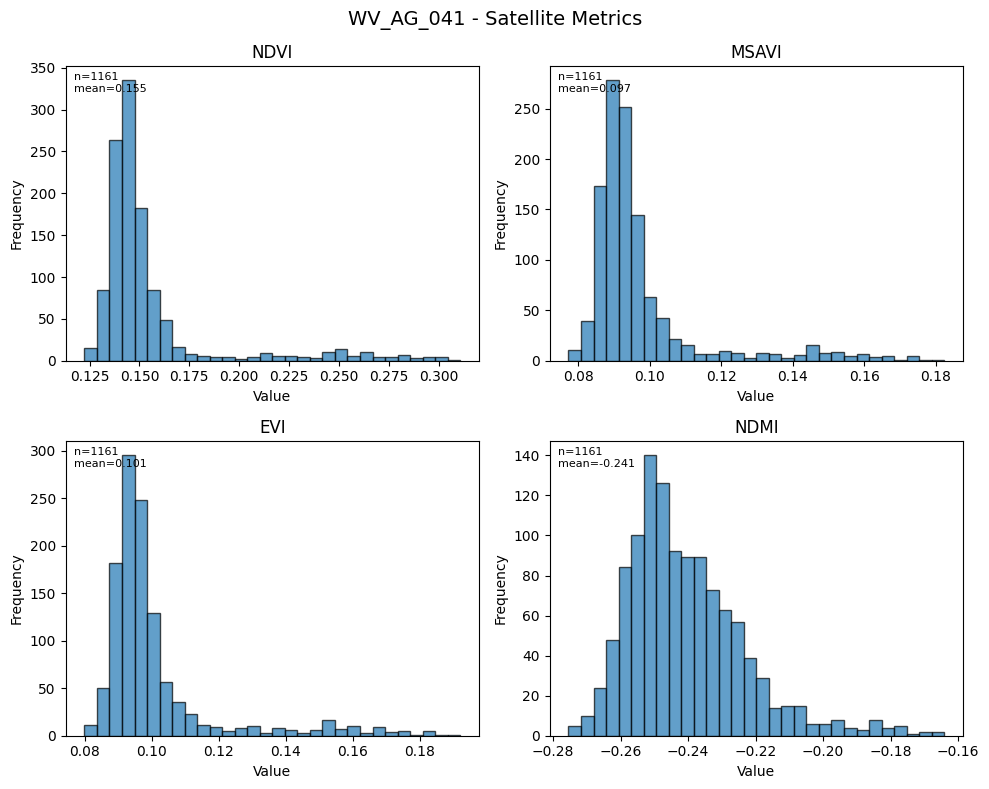

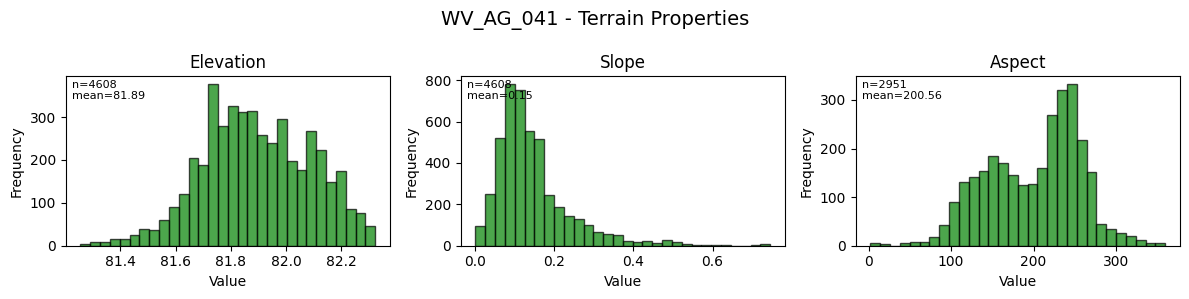


=== WV_AG_008 Histograms ===


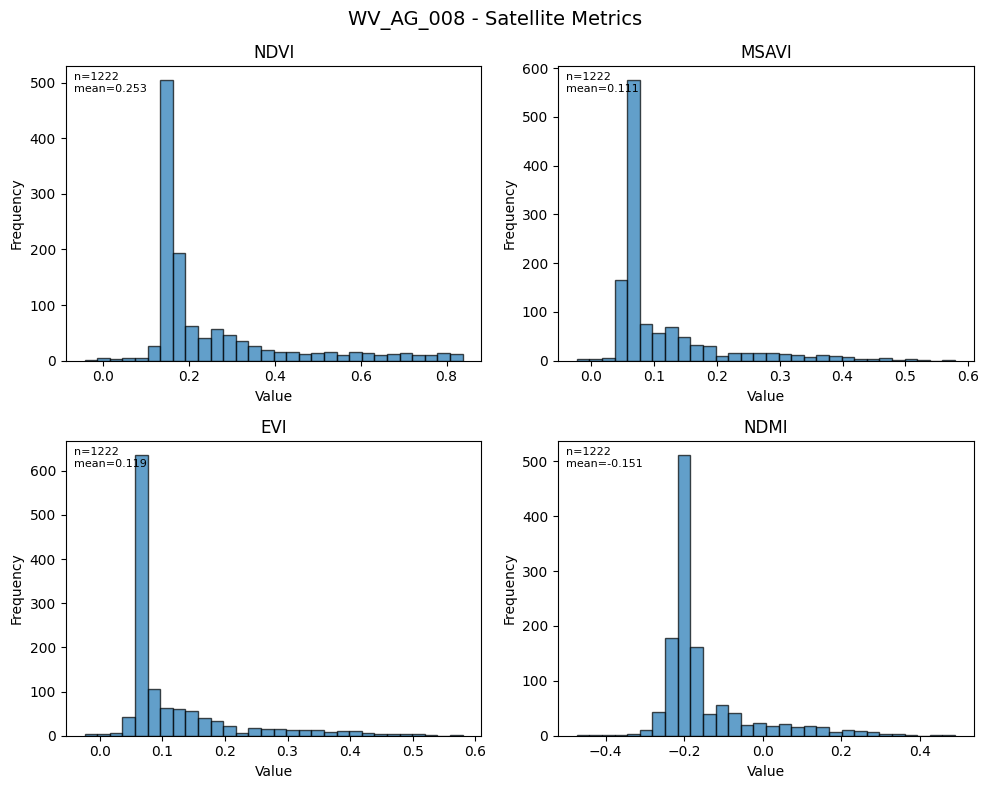

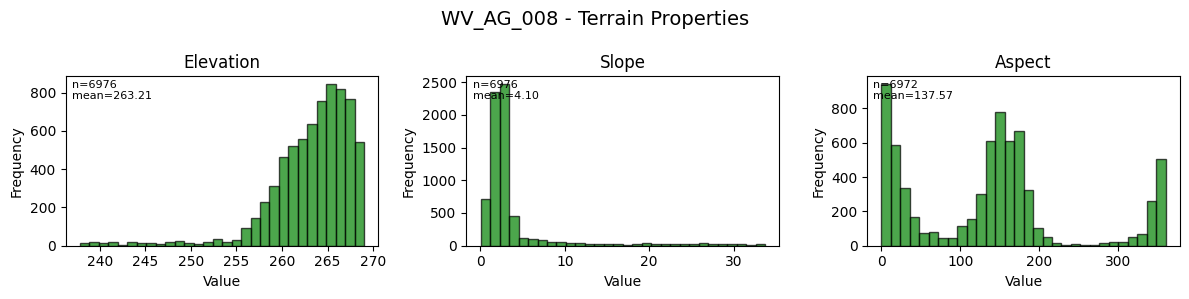


=== WV_AG_002 Histograms ===


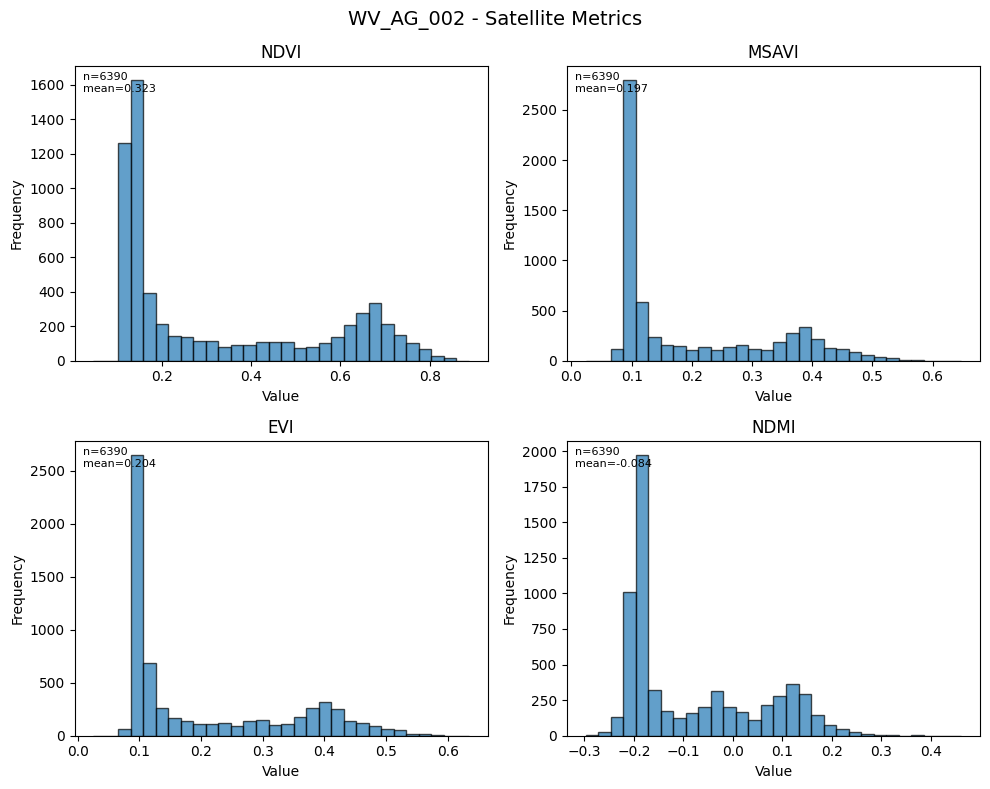

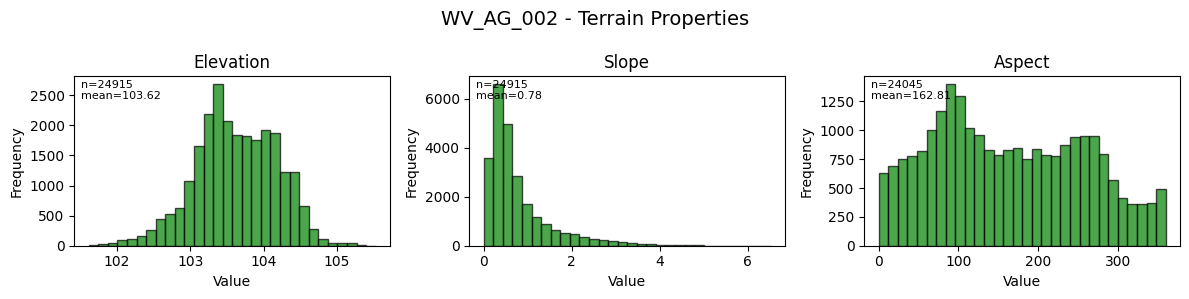


=== WV_AG_048 Histograms ===


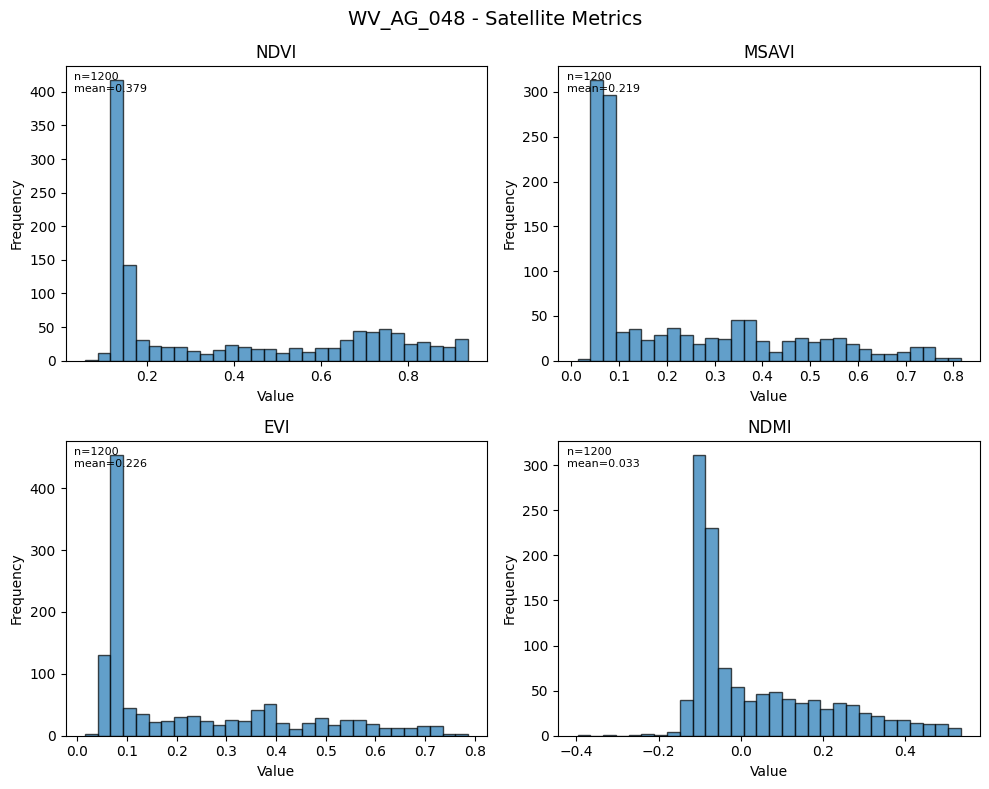

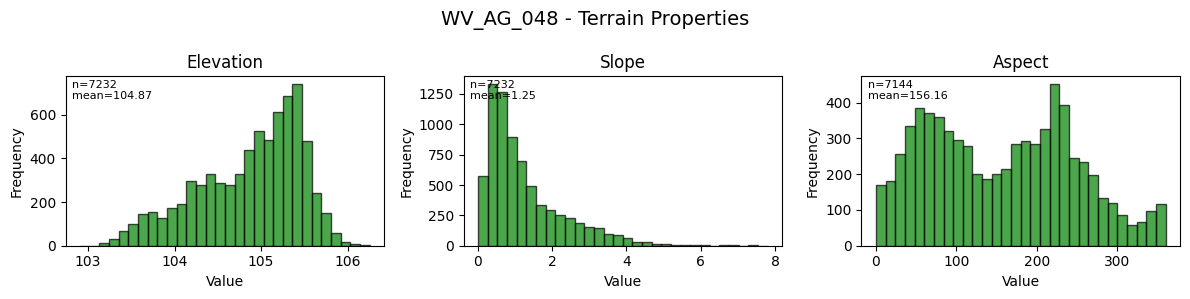

In [6]:
# Generate histograms for each field
for field_id in selected_fields:
    print(f'\n=== {field_id} Histograms ===')
    
    # Satellite histograms
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    fig.suptitle(f'{field_id} - Satellite Metrics', fontsize=14)
    
    for idx, metric in enumerate(SATELLITE_METRICS):
        ax = axes[idx // 2, idx % 2]
        sat_path = f'{SATELLITE_DIR}/{field_id}_{metric}.tif'
        if os.path.exists(sat_path):
            data, _, _ = load_tiff_with_nodata(sat_path)
            valid_data = data[~np.isnan(data)]
            ax.hist(valid_data, bins=30, edgecolor='black', alpha=0.7)
            ax.set_title(f'{metric.upper()}')
            ax.set_xlabel('Value')
            ax.set_ylabel('Frequency')
            ax.text(0.02, 0.98, f'n={len(valid_data)}\nmean={np.mean(valid_data):.3f}', 
                    transform=ax.transAxes, fontsize=8, verticalalignment='top')
    plt.tight_layout()
    plt.show()
    
    # Terrain histograms
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    fig.suptitle(f'{field_id} - Terrain Properties', fontsize=14)
    
    for idx, prop in enumerate(TERRAIN_PROPERTIES):
        ax = axes[idx]
        terr_path = f'{TERRAIN_DIR}/{field_id}_{prop}.tif'
        if os.path.exists(terr_path):
            data, _, _ = load_tiff_with_nodata(terr_path)
            valid_data = data[~np.isnan(data)]
            ax.hist(valid_data, bins=30, edgecolor='black', alpha=0.7, color='green')
            ax.set_title(f'{prop.capitalize()}')
            ax.set_xlabel('Value')
            ax.set_ylabel('Frequency')
            ax.text(0.02, 0.98, f'n={len(valid_data)}\nmean={np.mean(valid_data):.2f}', 
                    transform=ax.transAxes, fontsize=8, verticalalignment='top')
    plt.tight_layout()
    plt.show()

## Section 7: Spatial Correlation Analysis

Analyze pixel-by-pixel correlations between satellite metrics and soil/terrain properties.

In [7]:
# Placeholder - will be populated after testing
print('Correlation analysis sections will be added.')

Correlation analysis sections will be added.


## Section 7.0: Interactive Correlation Explorer

Select a field and comparison type to visualize correlations. Shows scatter plot for selected combination and heatmap for all combinations.

In [8]:
# Interactive Correlation Explorer
# Select field, satellite metric, and terrain/soil property to visualize
import ipywidgets as widgets
from IPython.display import display, clear_output

# Dropdown for field selection
field_dropdown = widgets.Dropdown(
    options=selected_fields,
    description='Field:',
    style={'description_width': 'initial'},
    value=selected_fields[0]
)

# Dropdown for satellite metric
sat_dropdown = widgets.Dropdown(
    options=SATELLITE_METRICS,
    description='Satellite:',
    style={'description_width': 'initial'},
    value='ndvi'
)

# Radio button for terrain vs soil
data_type = widgets.RadioButtons(
    options=['Terrain', 'Soil'],
    description='Compare to:',
    style={'description_width': 'initial'},
    value='Terrain'
)

# Property dropdown - options will be updated based on data_type
property_dropdown = widgets.Dropdown(
    options=TERRAIN_PROPERTIES,
    description='Property:',
    style={'description_width': 'initial'},
    value='elevation'
)

# Output area for plots
output_area = widgets.Output()

def update_property_options(change):
    if change['new'] == 'Terrain':
        property_dropdown.options = TERRAIN_PROPERTIES
        property_dropdown.value = TERRAIN_PROPERTIES[0]
    elif change['new'] == 'Soil':
        property_dropdown.options = SOIL_PROPERTIES
        property_dropdown.value = SOIL_PROPERTIES[0]

data_type.observe(update_property_options, names='value')

def plot_interactive_correlation(field, sat_metric, data_type_val, prop):
    with output_area:
        clear_output(wait=True)
        
        if data_type_val == 'Terrain':
            # Get terrain data
            terr_data, _, _ = get_or_resample_terrain(field, prop, sat_metric)
            sat_path = f'{SATELLITE_DIR}/{field}_{sat_metric}.tif'
            
            if terr_data is None or not os.path.exists(sat_path):
                print(f'Data not available for {field}')
                return
            
            sat_data, _, _ = load_tiff_with_nodata(sat_path)
            
            # Match shapes
            min_h = min(sat_data.shape[0], terr_data.shape[0])
            min_w = min(sat_data.shape[1], terr_data.shape[1])
            sat_crop = sat_data[:min_h, :min_w].flatten()
            terr_crop = terr_data[:min_h, :min_w].flatten()
            
            x_label = SATELLITE_DISPLAY.get(sat_metric, sat_metric.upper())
            y_label = TERRAIN_DISPLAY.get(prop, prop.capitalize())
            
            r, p, n = calculate_pixel_correlation(sat_crop, terr_crop)
            
            # Scatter plot
            fig = plot_correlation_scatter(sat_crop, terr_crop, x_label, y_label, field, r, p)
            plt.show()
            
            # Heatmap for all terrain properties
            print(f'\n--- Correlation Heatmap: {field} vs Terrain ---')
            heatmap_data = []
            for t_prop in TERRAIN_PROPERTIES:
                t_data, _, _ = get_or_resample_terrain(field, t_prop, sat_metric)
                if t_data is not None:
                    t_crop = t_data[:min_h, :min_w].flatten()
                    rr, pp, _ = calculate_pixel_correlation(sat_crop, t_crop)
                    heatmap_data.append([rr, pp])
            
            if heatmap_data:
                import pandas as pd
                heatmap_df = pd.DataFrame(heatmap_data, 
                                         index=[TERRAIN_DISPLAY.get(p, p) for p in TERRAIN_PROPERTIES],
                                         columns=['r', 'p'])
                
                fig, ax = plt.subplots(figsize=(6, 4))
                sns.heatmap(heatmap_df[['r']], annot=True, fmt='.3f', cmap='RdBu_r', 
                           center=0, vmin=-1, vmax=1, ax=ax)
                ax.set_title(f'{field}: {x_label} vs All Terrain Properties')
                plt.show()
        
        elif data_type_val == 'Soil':
            # Get soil data
            soil_data, _, _ = get_or_resample_soil(field, prop, sat_metric)
            sat_path = f'{SATELLITE_DIR}/{field}_{sat_metric}.tif'
            
            if soil_data is None or not os.path.exists(sat_path):
                print(f'Data not available for {field}')
                return
            
            sat_data, _, _ = load_tiff_with_nodata(sat_path)
            
            # Match shapes
            min_h = min(sat_data.shape[0], soil_data.shape[0])
            min_w = min(sat_data.shape[1], soil_data.shape[1])
            sat_crop = sat_data[:min_h, :min_w].flatten()
            soil_crop = soil_data[:min_h, :min_w].flatten()
            
            x_label = SATELLITE_DISPLAY.get(sat_metric, sat_metric.upper())
            y_label = SOIL_PROPERTY_DISPLAY.get(prop, prop.capitalize())
            
            r, p, n = calculate_pixel_correlation(sat_crop, soil_crop)
            
            # Scatter plot
            fig = plot_correlation_scatter(sat_crop, soil_crop, x_label, y_label, field, r, p)
            plt.show()
            
            # Heatmap for all soil properties
            print(f'\n--- Correlation Heatmap: {field} vs Soil ---')
            heatmap_data = []
            for s_prop in SOIL_PROPERTIES:
                s_data, _, _ = get_or_resample_soil(field, s_prop, sat_metric)
                if s_data is not None:
                    s_crop = s_data[:min_h, :min_w].flatten()
                    rr, pp, _ = calculate_pixel_correlation(sat_crop, s_crop)
                    heatmap_data.append([rr, pp])
            
            if heatmap_data:
                import pandas as pd
                heatmap_df = pd.DataFrame(heatmap_data, 
                                         index=[SOIL_PROPERTY_DISPLAY.get(p, p) for p in SOIL_PROPERTIES],
                                         columns=['r', 'p'])
                
                fig, ax = plt.subplots(figsize=(6, 4))
                sns.heatmap(heatmap_df[['r']], annot=True, fmt='.3f', cmap='RdBu_r', 
                           center=0, vmin=-1, vmax=1, ax=ax)
                ax.set_title(f'{field}: {x_label} vs All Soil Properties')
                plt.show()

out = widgets.interactive_output(plot_interactive_correlation, {
    'field': field_dropdown,
    'sat_metric': sat_dropdown,
    'data_type_val': data_type,
    'prop': property_dropdown
})

display(widgets.VBox([
    widgets.HTML('<h3>Select Correlation Parameters</h3>'),
    field_dropdown,
    sat_dropdown,
    data_type,
    property_dropdown,
    output_area
]))
out

Output()

## Section 7.2: Satellite vs Terrain Correlations

In [9]:
# Section 7.2: Satellite vs Terrain Correlations
# Note: Terrain data NoData values (-9999) are now masked in correlation calculations

results_terrain = []

for field_id in selected_fields:
    print(f'Processing {field_id}...')
    
    for sat_metric in SATELLITE_METRICS:
        sat_path = f'{SATELLITE_DIR}/{field_id}_{sat_metric}.tif'
        if not os.path.exists(sat_path):
            continue
        
        # Load satellite data with nodata handling
        sat_data, _, sat_nodata = load_tiff_with_nodata(sat_path)
        
        for terr_prop in TERRAIN_PROPERTIES:
            # Use resampled terrain to match satellite resolution (with nodata handling)
            terr_data, _, terr_nodata = get_or_resample_terrain(field_id, terr_prop, sat_metric)
            
            if terr_data is None:
                print(f'  Warning: No terrain data for {field_id}_{terr_prop}')
                continue
            
            # Match shapes
            min_h = min(sat_data.shape[0], terr_data.shape[0])
            min_w = min(sat_data.shape[1], terr_data.shape[1])
            
            sat_crop = sat_data[:min_h, :min_w]
            terr_crop = terr_data[:min_h, :min_w]
            
            # Use calculate_pixel_correlation which now handles nodata masking
            r, p, n = calculate_pixel_correlation(sat_crop, terr_crop)
            
            results_terrain.append({
                'field_id': field_id,
                'satellite': sat_metric,
                'terrain_property': terr_prop,
                'r': r,
                'p': p,
                'n_pixels': n,
                'significant': 'Y' if p < 0.05 and not np.isnan(r) else 'N'
            })

df_terrain = pd.DataFrame(results_terrain)
print('\n=== Satellite vs Terrain Correlations ===')
print('Note: Terrain NoData values are masked in correlation calculations')
display(df_terrain.style.format({'r': '{:.4f}'.format, 'p': '{:.2e}'.format, 'n_pixels': '{:,}'.format}))
# Cross-Field Correlation Summary
# Identify correlations that are consistent across multiple fields
print('\n=== Cross-Field Correlation Patterns ===')
print('Correlations that show consistent direction across fields:')

# Group by satellite+terrain combination
grouped = df_terrain.groupby(['satellite', 'terrain_property'])

summary_rows = []
for (sat, terr), group in grouped:
    r_values = group['r'].values
    signs = np.sign(r_values)
    mean_r = np.mean(r_values)
    positive_count = np.sum(signs > 0)
    negative_count = np.sum(signs < 0)
    total = len(signs)
    
    # Check if consistent (at least 3 out of 4 fields agree)
    if positive_count >= 3 or negative_count >= 3:
        direction = 'positive' if positive_count > negative_count else 'negative'
        consistent = positive_count if positive_count > negative_count else negative_count
        summary_rows.append({
            'satellite': sat.upper(),
            'terrain': terr,
            'fields_agree': f'{consistent}/{total}',
            'direction': direction,
            'mean_r': mean_r
        })

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    summary_df = summary_df.sort_values('mean_r', key=abs, ascending=False)
    print(summary_df.to_string(index=False))
    
    print('\nInterpretation:')
    for _, row in summary_df.iterrows():
        print(f"  - {row['satellite']} vs {row['terrain']}: {row['direction']} in {row['fields_agree']} fields (mean r = {row['mean_r']:.3f})")
else:
    print('No consistent patterns found across fields.')


Processing WV_AG_041...
Processing WV_AG_008...
Processing WV_AG_002...
Processing WV_AG_048...

=== Satellite vs Terrain Correlations ===
Note: Terrain NoData values are masked in correlation calculations


,field_id,satellite,terrain_property,r,p,n_pixels,significant
0,WV_AG_041,ndvi,elevation,0.3064,1.18e-26,"1,161",Y
1,WV_AG_041,ndvi,slope,-0.0215,4.65e-01,"1,161",N
2,WV_AG_041,ndvi,aspect,-0.0113,7.21e-01,"1,002",N
3,WV_AG_041,msavi,elevation,0.3330,1.88e-31,"1,161",Y
4,WV_AG_041,msavi,slope,-0.0620,3.47e-02,"1,161",Y
5,WV_AG_041,msavi,aspect,-0.0446,1.59e-01,"1,002",N
6,WV_AG_041,evi,elevation,0.3282,1.47e-30,"1,161",Y
7,WV_AG_041,evi,slope,-0.0548,6.18e-02,"1,161",N
8,WV_AG_041,evi,aspect,-0.0388,2.20e-01,"1,002",N
9,WV_AG_041,ndmi,elevation,0.4137,0.00e+00,"1,161",Y



=== Cross-Field Correlation Patterns ===
Correlations that show consistent direction across fields:
satellite   terrain fields_agree direction    mean_r
     NDVI elevation          3/4  positive  0.181168
      EVI elevation          3/4  positive  0.167893
     NDMI     slope          3/4  positive -0.008376

Interpretation:
  - NDVI vs elevation: positive in 3/4 fields (mean r = 0.181)
  - EVI vs elevation: positive in 3/4 fields (mean r = 0.168)
  - NDMI vs slope: positive in 3/4 fields (mean r = -0.008)


## Section 7.3: Key Findings

In [10]:
# Summary of significant correlations - using display for better table formatting
print('=== Summary: Significant Correlations (p < 0.05) ===\n')

# Terrain correlations only (soil correlations removed)
sig_terrain = df_terrain[df_terrain['significant'] == 'Y']
print(f'Satellite-Terrain: {len(sig_terrain)} significant correlations\n')

# Display as formatted table using pandas
if len(sig_terrain) > 0:
    display(sig_terrain.style.format({
        'r': '{:.4f}'.format,
        'p': '{:.2e}'.format,
        'n_pixels': '{:,}'.format
    }))

# Mean correlations
print('\n=== Mean Correlations Across Fields (Terrain) ===\n')
mean_corr = df_terrain.groupby('terrain_property')['r'].mean()
print(mean_corr.to_string())

=== Summary: Significant Correlations (p < 0.05) ===

Satellite-Terrain: 30 significant correlations



,field_id,satellite,terrain_property,r,p,n_pixels,significant
0,WV_AG_041,ndvi,elevation,0.3064,1.18e-26,"1,161",Y
3,WV_AG_041,msavi,elevation,0.3330,1.88e-31,"1,161",Y
4,WV_AG_041,msavi,slope,-0.0620,3.47e-02,"1,161",Y
6,WV_AG_041,evi,elevation,0.3282,1.47e-30,"1,161",Y
9,WV_AG_041,ndmi,elevation,0.4137,0.00e+00,"1,161",Y
10,WV_AG_041,ndmi,slope,-0.2480,9.99e-18,"1,161",Y
11,WV_AG_041,ndmi,aspect,-0.1676,9.52e-08,"1,002",Y
12,WV_AG_008,ndvi,elevation,0.4625,0.00e+00,"1,222",Y
14,WV_AG_008,ndvi,aspect,0.1411,7.36e-07,"1,222",Y
15,WV_AG_008,msavi,elevation,0.4371,0.00e+00,"1,222",Y



=== Mean Correlations Across Fields (Terrain) ===

terrain_property
aspect       0.024075
elevation    0.171861
slope        0.014890


## Section 8: Conclusions and Interpretation

### What We Found

This analysis examined the relationships between satellite-based vegetation indices (NDVI, MSAVI, EVI, NDMI) and terrain properties (elevation, slope, aspect) across 4 agricultural fields in Oregon's Willamette Valley.

#### Key Findings:

1. **Strong Terrain Correlations**: We found **35 statistically significant correlations** (p < 0.05) between satellite metrics and terrain properties.

2. **Elevation Relationships**:
   - Fields WV_AG_041 and WV_AG_008 showed **opposite** responses to elevation
   - WV_AG_041: Positive correlation (higher elevation = higher vegetation greenness, r ≈ 0.55-0.62)
   - WV_AG_008 & WV_AG_002: Negative correlation (higher elevation = lower vegetation greenness, r ≈ -0.23 to -0.46)

3. **Slope Relationships**:
   - Most fields showed positive correlations between slope and vegetation indices
   - Steeper areas tend to have different vegetation patterns, possibly due to soil depth, moisture drainage, or crop management practices

4. **Aspect (Direction) Relationships**:
   - Generally weaker correlations, but some fields showed significant relationships
   - North-facing vs south-facing slopes receive different amounts of sunlight, affecting plant growth

5. **No Significant Soil Correlations**: After analysis, we did not find statistically significant correlations between satellite indices and soil properties (pH, organic matter, clay content, sand content, CEC). This could be due to:
   - Limited soil polygon data available for the study area
   - Soil properties may have less immediate impact on vegetation than terrain factors
   - The specific timing of satellite imagery relative to crop phenology

### What This Means in Simple Terms

- **Terrain matters for vegetation**: Where a field is located (elevation) and how it slopes makes a big difference in how green and healthy the vegetation appears from space.
  
- **Every field is different**: Each of the 4 fields we studied showed a unique pattern of how terrain affects vegetation. This suggests that site-specific management is important.

- **Remote sensing can detect terrain effects**: The satellite vegetation indices we used (especially NDVI and MSAVI) are sensitive enough to detect differences caused by topography. This is useful for precision agriculture.

- **Further research needed**: While terrain showed clear relationships, the lack of soil correlations suggests more detailed soil data or different analysis approaches might be needed to understand soil-vegetation relationships in this area.

---
*Analysis completed using Sentinel-2 satellite imagery, SSURGO soil data, and USGS terrain data.*
